# RFM Analysis — Customer Segmentation

## What is RFM Analysis?

**RFM** stands for **Recency**, **Frequency**, and **Monetary value**. It is a customer segmentation technique that uses three behavioral metrics derived from transaction data:

- **Recency**: How recently did the customer make a purchase? (e.g. days since last order)
- **Frequency**: How often do they buy? (e.g. number of orders or transactions)
- **Monetary**: How much do they spend? (e.g. total revenue or average order value)

Each customer is scored on these three dimensions. By grouping customers with similar RFM profiles (e.g. via quartiles or custom thresholds), you obtain segments such as "Champions" (recent, frequent, high spenders), "At Risk" (were good but haven't bought lately), or "New" (recent but few orders and low spend).

## How RFM Adds Value in E‑commerce

For an e‑commerce dataset like Online Retail:

1. **Targeted marketing**: Send different campaigns to different segments—e.g. win-back emails to low Recency customers, loyalty rewards to high Frequency/Monetary customers.
2. **Resource allocation**: Focus retention efforts and premium support on high-value (high Monetary/Frequency) customers.
3. **Churn risk**: Low Recency with previously high Frequency/Monetary often indicates churn; you can trigger reactivation campaigns.
4. **Lifetime value (LTV)**: RFM segments help estimate which customers are likely to contribute more revenue in the future.
5. **Product and pricing**: High Monetary segments may respond to upsells or premium bundles; low Monetary segments to discounts or entry-level products.

## What We Can Learn From This Dataset

Using the Online Retail data (InvoiceNo, InvoiceDate, CustomerID, Quantity, UnitPrice), we can compute:

- **Recency**: Days since each customer's last order (from a reference date, e.g. day after the last transaction in the data).
- **Frequency**: Number of distinct invoices per customer.
- **Monetary**: Total revenue (Quantity × UnitPrice) per customer.

From these metrics we can build RFM scores (e.g. 1–5 by quintile), label segments (e.g. Champions, Loyal, At Risk, Lost), and use the resulting table for further analysis or campaign planning—without interpreting specific numbers here; that comes after you run the code below.

## 1. Load data and apply same cleaning as main analysis

In [6]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Same cleaning as retail_data_analysis.ipynb
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna(subset=["CustomerID"])
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C", na=False)]
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print("Cleaned shape:", df_clean.shape)
print("Date range:", df_clean["InvoiceDate"].min(), "to", df_clean["InvoiceDate"].max())
df_clean.head()

Cleaned shape: (392692, 9)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 2. Compute RFM metrics per customer

- **Reference date**: day after the last transaction in the dataset (so "days since last order" is well-defined).
- **Recency**: days from each customer's last order to the reference date.
- **Frequency**: number of distinct invoices per customer.
- **Monetary**: total revenue per customer.

In [14]:
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
).reset_index()

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


## 3. RFM scores (quintiles)

Score each metric from 1 to 5 by quintile (5 equal groups). For all three **scores**, higher is better (5 = best):

- **R_Score (Recency)**: The raw Recency metric is *days since last order* — fewer days means more recent, which is better. We therefore assign **R_Score = 5** to the smallest Recency values (most recent customers) and **R_Score = 1** to the largest (least recent). So **higher R_Score = more recent**.
- **F_Score, M_Score**: For Frequency and Monetary, higher raw values are better, so we assign 5 to the largest values and 1 to the smallest.

Also compute **RFM_Sum** = R_Score + F_Score + M_Score.

In [15]:
# Quintiles: 5 equal groups. Recency: lower is better → assign 5 to lowest (most recent)
rfm["R_Score"] = pd.qcut(rfm["Recency"].rank(method="first"), q=5, labels=[5, 4, 3, 2, 1], duplicates="drop")
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5], duplicates="drop")
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5], duplicates="drop")

rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)
rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm["RFM_Sum"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum
0,12346.0,326,1,77183.60,1,1,5,115,7
1,12347.0,2,7,4310.00,5,5,5,555,15
2,12348.0,75,4,1797.24,2,4,4,244,10
3,12349.0,19,1,1757.55,4,1,4,414,9
4,12350.0,310,1,334.40,1,1,2,112,4
5,12352.0,36,8,2506.04,3,5,5,355,13
6,12353.0,204,1,89.00,1,1,1,111,3
7,12354.0,232,1,1079.40,1,1,4,114,6
8,12355.0,214,1,459.40,1,1,2,112,4
9,12356.0,23,3,2811.43,4,3,5,435,12


## 4. Segment labels (by R and combined F+M)

Assign a segment name to each customer based on R_Score and a simple combination of F_Score and M_Score (e.g. Champions: recent and high value; At Risk: not recent but previously valuable).

**How we categorize the 6 segments**

We use the quintile scores **R_Score** (1–5; higher = more recent, so 5 = most recent), **F_Score**, and **M_Score** (1–5; higher = better for both). The combination **F_Score + M_Score** (range 2–10) reflects “value” (how often they buy and how much they spend). The rules are:

| Segment     | Criteria | Meaning |
|------------|----------|--------|
| **Champions** | R ≥ 4 and (F + M) ≥ 8 | Recent buyers, high frequency and spend — best customers. |
| **Loyal**     | R ≥ 3 and (F + M) ≥ 6 | Recently active and solid value — regular customers. |
| **Potential** | R ≥ 3 and (F + M) ≤ 4 | Recent but low frequency/spend — room to grow. |
| **At Risk**   | R ≤ 2 and (F + M) ≥ 6 | Not recent but previously high value — need reactivation. |
| **Lost**      | R ≤ 2 and (F + M) ≤ 4 | Not recent and low value — likely churned. |
| **Other**     | All remaining         | Middle patterns that don’t fit the above. |

In [16]:
def rfm_segment(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    # 5-point scale: R 1-5, F+M 2-10
    if r >= 4 and (f + m) >= 8:
        return "Champions"
    if r >= 3 and (f + m) >= 6:
        return "Loyal"
    if r >= 3 and (f + m) <= 4:
        return "Potential"
    if r <= 2 and (f + m) >= 6:
        return "At Risk"
    if r <= 2 and (f + m) <= 4:
        return "Lost"
    return "Other"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum,Segment
0,12346.0,326,1,77183.60,1,1,5,115,7,At Risk
1,12347.0,2,7,4310.00,5,5,5,555,15,Champions
2,12348.0,75,4,1797.24,2,4,4,244,10,At Risk
3,12349.0,19,1,1757.55,4,1,4,414,9,Other
4,12350.0,310,1,334.40,1,1,2,112,4,Lost
5,12352.0,36,8,2506.04,3,5,5,355,13,Loyal
6,12353.0,204,1,89.00,1,1,1,111,3,Lost
7,12354.0,232,1,1079.40,1,1,4,114,6,Other
8,12355.0,214,1,459.40,1,1,2,112,4,Lost
9,12356.0,23,3,2811.43,4,3,5,435,12,Champions


## 5. RFM table summary

In [17]:
print("Reference date for Recency:", reference_date.date())
print("\nRFM metrics summary:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe())
print("\nSegment counts:")
print(rfm["Segment"].value_counts().sort_index())
print("\nFull RFM table (first 20 rows):")
rfm.head(20)

Reference date for Recency: 2011-12-10

RFM metrics summary:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000

Segment counts:
Segment
At Risk      542
Champions    971
Lost         945
Loyal        836
Other        462
Potential    582
Name: count, dtype: int64

Full RFM table (first 20 rows):


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum,Segment
0,12346.0,326,1,77183.60,1,1,5,115,7,At Risk
1,12347.0,2,7,4310.00,5,5,5,555,15,Champions
2,12348.0,75,4,1797.24,2,4,4,244,10,At Risk
3,12349.0,19,1,1757.55,4,1,4,414,9,Other
4,12350.0,310,1,334.40,1,1,2,112,4,Lost
5,12352.0,36,8,2506.04,3,5,5,355,13,Loyal
6,12353.0,204,1,89.00,1,1,1,111,3,Lost
7,12354.0,232,1,1079.40,1,1,4,114,6,Other
8,12355.0,214,1,459.40,1,1,2,112,4,Lost
9,12356.0,23,3,2811.43,4,3,5,435,12,Champions


## 6. Segments analysis

For each segment: number of customers, customer share (%), average Recency/Frequency/Monetary, total revenue, and revenue share (%). Then visualize with bar and pie charts.

In [18]:
segment_order = ["Champions", "Loyal", "Potential", "At Risk", "Lost", "Other"]

segment_stats = rfm.groupby("Segment").agg(
    Num_Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum"),
).reset_index()

total_customers = segment_stats["Num_Customers"].sum()
total_revenue = segment_stats["Total_Revenue"].sum()
segment_stats["Customer_Pct"] = round(100 * segment_stats["Num_Customers"] / total_customers, 2)
segment_stats["Revenue_Pct"] = round(100 * segment_stats["Total_Revenue"] / total_revenue, 2)
segment_stats["Avg_Recency"] = round(segment_stats["Avg_Recency"], 2)
segment_stats["Avg_Frequency"] = round(segment_stats["Avg_Frequency"], 2)
segment_stats["Avg_Monetary"] = round(segment_stats["Avg_Monetary"], 2)

# Order by segment_order (keep only segments that exist)
segment_stats["Segment"] = pd.Categorical(segment_stats["Segment"], categories=segment_order, ordered=True)
segment_stats = segment_stats.sort_values("Segment").reset_index(drop=True)
segment_stats

,Segment,Num_Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Pct,Revenue_Pct
0,Champions,971,12.61,11.00,6140.90,5962810.340,22.38,67.09
1,Loyal,836,35.15,3.94,1568.33,1311123.531,19.27,14.75
2,Potential,582,35.65,1.18,272.29,158471.160,13.42,1.78
3,At Risk,542,143.22,3.61,1765.08,956673.492,12.49,10.76
4,Lost,945,221.64,1.09,258.54,244320.501,21.78,2.75
5,Other,462,112.48,1.90,549.37,253809.870,10.65,2.86


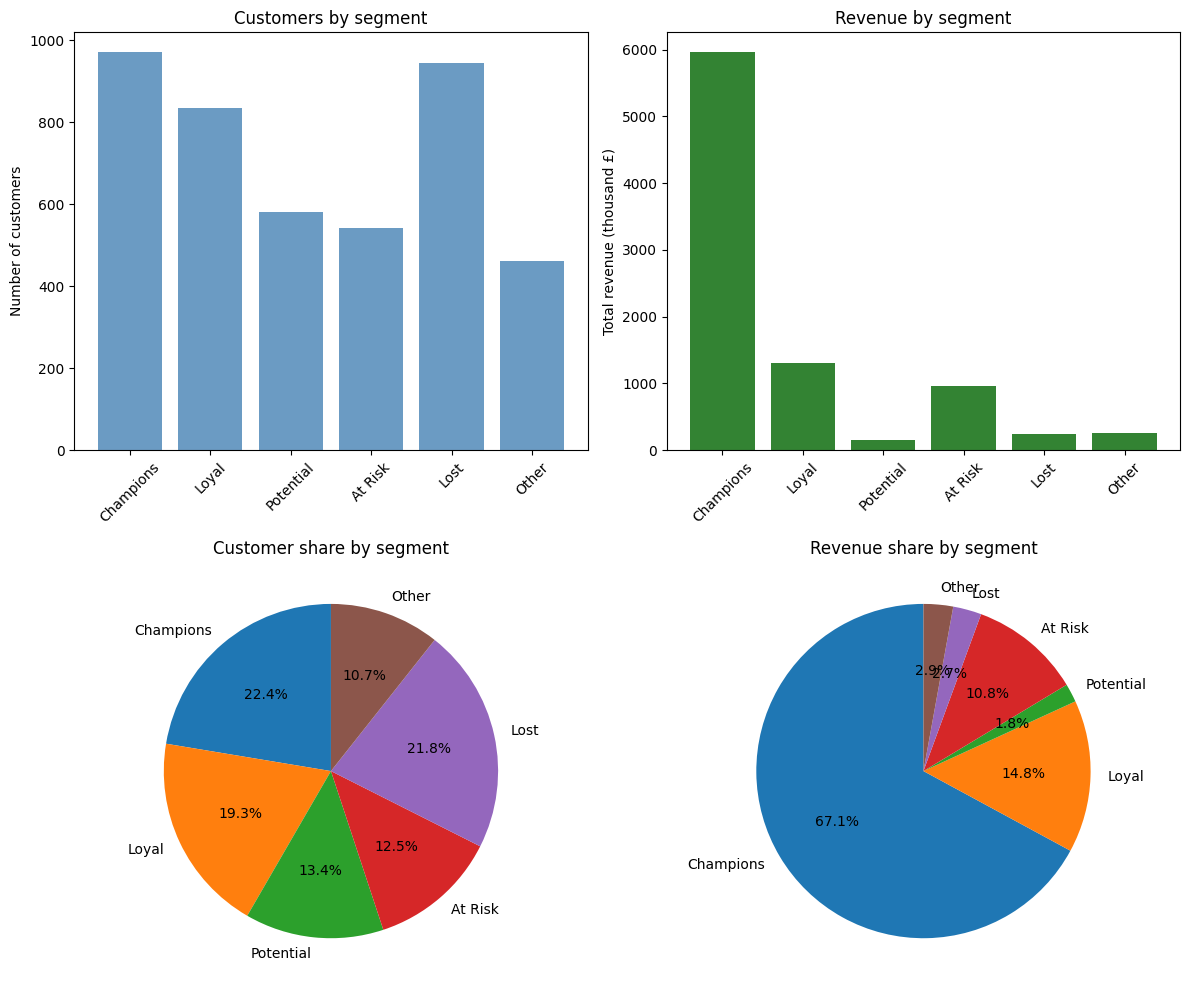

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Bar chart: number of customers by segment
ax1 = axes[0, 0]
bars1 = ax1.bar(segment_stats["Segment"], segment_stats["Num_Customers"], color="steelblue", alpha=0.8)
ax1.set_ylabel("Number of customers")
ax1.set_title("Customers by segment")
ax1.tick_params(axis="x", rotation=45)

# 2. Bar chart: total revenue by segment (in thousands)
ax2 = axes[0, 1]
bars2 = ax2.bar(segment_stats["Segment"], segment_stats["Total_Revenue"] / 1e3, color="darkgreen", alpha=0.8)
ax2.set_ylabel("Total revenue (thousand £)")
ax2.set_title("Revenue by segment")
ax2.tick_params(axis="x", rotation=45)

# 3. Pie chart: customer percentage by segment
ax3 = axes[1, 0]
ax3.pie(segment_stats["Num_Customers"], labels=segment_stats["Segment"], autopct="%1.1f%%", startangle=90)
ax3.set_title("Customer share by segment")

# 4. Pie chart: revenue percentage by segment
ax4 = axes[1, 1]
ax4.pie(segment_stats["Total_Revenue"], labels=segment_stats["Segment"], autopct="%1.1f%%", startangle=90)
ax4.set_title("Revenue share by segment")

plt.tight_layout()
plt.show()

---

# Key insights and recommendations

## Key insights (from the analysis output)

1. **Strong revenue concentration**  
   **Champions** (22% of customers) generate **67% of total revenue**. Together, Champions and Loyal account for about 42% of customers but roughly **82% of revenue**. A small share of customers drives most of the business.

2. **Lost is the largest segment by headcount but the smallest by value**  
   **Lost** has 945 customers (22% of the base) but only **2.75% of revenue**, with the lowest average frequency (1.09) and monetary (£258) and the highest average recency (222 days). This is a large pool of inactive or one-off buyers.

3. **At Risk: high value, slipping away**  
   **At Risk** (542 customers, 12.5% of base) still contributes **10.76% of revenue** with a high average monetary (£1,765), but average recency is **143 days** (vs. 13 days for Champions). These are previously valuable customers who have not purchased recently.

4. **Potential: recent but low value**  
   **Potential** (582 customers) has recency similar to Loyal (~35 days) but much lower frequency (1.18) and monetary (£272), and only **1.78% of revenue**. They are recent but light buyers—room to grow.

5. **Champions and Loyal have the best RFM profile**  
   Champions show the lowest average recency (13 days), highest frequency (11 orders) and monetary (£6,141). Loyal customers sit in the middle (35 days, ~4 orders, £1,568). These two segments are the core of current revenue.

---

## Priority matrix

| Segment     | Priority   | Action (keywords)                          | Expected impact |
|------------|------------|--------------------------------------------|-----------------|
| **Champions** | Critical | VIP program, exclusives, referral incentives | Retain 67% revenue; grow share of wallet |
| **At Risk**   | High     | Win-back emails, limited-time offer, "we miss you" | Recover ~11% revenue at risk of churn |
| **Loyal**     | High     | Engagement, cross-sell, upsell             | Prevent slip to At Risk; sustain ~15% revenue |
| **Potential** | Medium   | Recommendations, second-purchase offer, bundles | Convert to Loyal; grow from 1.8% revenue |
| **Other**     | Medium   | Refine rules, segment-specific campaigns   | Reclassify or unlock incremental value |
| **Lost**      | Low      | Low-cost win-back or accept churn          | Avoid wasted spend; optional recovery of 2.75% |

---

## Recommendations

| Segment    | Recommendation |
|-----------|----------------|
| **Champions** | Protect and reward: VIP/loyalty program, early access or exclusive offers, referral incentives. Aim to retain and increase share of wallet. |
| **Loyal**    | Keep engaged with relevant communication and offers so they do not slip to At Risk. Consider light cross-sell/upsell. |
| **Potential**| Nurture: product recommendations, “second purchase” or bundle offers, simple loyalty perks to increase frequency and spend. |
| **At Risk**  | Prioritize reactivation: personalized win-back emails, limited-time discount or free shipping, “we miss you” messaging. Track response and ROI. |
| **Lost**     | Either low-cost reactivation (e.g. one-off win-back campaign) or accept churn and avoid costly mass marketing. Use budget where ROI is higher (e.g. At Risk, Potential). |
| **Other**    | Review behavior (e.g. by RFM_Score or country) to refine rules or target with segment-specific campaigns. |

---

## Overall summary

**Where to focus:** Use the **priority matrix** above to allocate effort: **Critical** on Champions (retain 67% of revenue); **High** on At Risk (win back ~11% at risk) and Loyal (avoid slip, sustain ~15%); **Medium** on Potential (grow from 1.8%) and Other (refine targeting); **Low** on Lost (optional low-cost win-back or accept churn). Re-run RFM periodically and adjust thresholds and actions based on segment counts, revenue share, and campaign results.

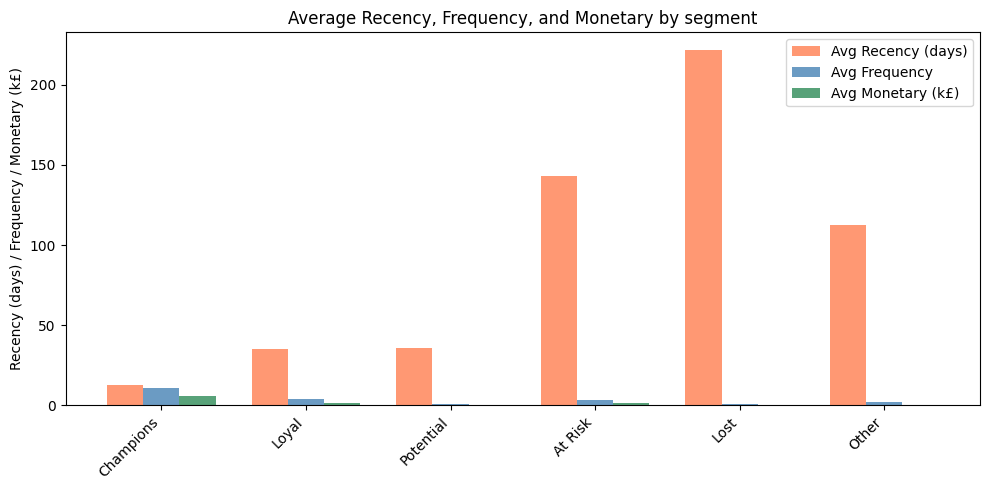

In [20]:
# Average RFM metrics by segment (normalized for comparison: each metric scaled to 0–1 for display)
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(segment_stats))
w = 0.25
ax.bar([i - w for i in x], segment_stats["Avg_Recency"], width=w, label="Avg Recency (days)", color="coral", alpha=0.8)
ax.bar([i for i in x], segment_stats["Avg_Frequency"], width=w, label="Avg Frequency", color="steelblue", alpha=0.8)
ax.bar([i + w for i in x], segment_stats["Avg_Monetary"] / 1000, width=w, label="Avg Monetary (k£)", color="seagreen", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(segment_stats["Segment"], rotation=45, ha="right")
ax.set_ylabel("Recency (days) / Frequency / Monetary (k£)")
ax.set_title("Average Recency, Frequency, and Monetary by segment")
ax.legend()
plt.tight_layout()
plt.show()